# 🔄 Autoencoders (Representation Learning & Generative Foundations)
---

## 📑 Table of Contents
1. [Introduction & Definition](#1.-Introduction-&-Definition)
2. [How It Works — Math & Intuition](#2.-How-It-Works-—-Math-&-Intuition)
3. [When To Use](#3.-When-To-Use)
4. [Pros & Cons](#4.-Pros-&-Cons)
5. [Dataset Upload & Exploration](#5.-Dataset-Upload-&-Exploration)
   - 5.1 Import Libraries
   - 5.2 Load Dataset
   - 5.3 Exploratory Data Analysis (EDA)
   - 5.4 Preprocessing & Feature Engineering
6. [Building & Training the Model](#6.-Building-&-Training-the-Model)
   - 6.1 Choosing the Key Hyperparameter(s)
   - 6.2 Training Loop
7. [Evaluation Without Labels](#7.-Evaluation-Without-Labels)
   - 7.1 Internal / Family-Specific Metrics
   - 7.2 Visual Evaluation
8. [Interpretation](#8.-Interpretation)
   - 8.1 Profiling the Output
   - 8.2 Sanity Check Against Known Labels
9. [Optimization / Hyperparameter Tuning](#9.-Optimization-/-Hyperparameter-Tuning)
   - 9.1 Systematic Search
   - 9.2 Best Parameters & Retrain
10. [Real-World / Second Dataset Application](#10.-Real-World-/-Second-Dataset-Application-(Denoising-&-Variational-Autoencoders))
11. [Tips & Tricks Summary](#11.-Tips-&-Tricks-Summary)
12. [Conclusion](#12.-Conclusion)

## 1. Introduction & Definition

The **Autoencoder** is this series' first genuinely **unsupervised/self-supervised** neural network — it needs no labels at all, learning instead by trying to reconstruct its own input after forcing that input through an information bottleneck. Where every previous notebook (MLP, CNN, RNN/LSTM, Transformer, GNN) learned to map inputs to externally-provided labels, an autoencoder's "label" is simply its own input — a training signal available for free, from any unlabeled dataset.

### 🧠 Formal Definition
An autoencoder pairs two networks: an **encoder** $f_\theta: \mathbb{R}^d \to \mathbb{R}^k$ compressing the input into a lower-dimensional **latent representation** ($k \ll d$), and a **decoder** $g_\phi: \mathbb{R}^k \to \mathbb{R}^d$ reconstructing the original input from that compressed code:
$$\hat{x} = g_\phi(f_\theta(x)), \qquad \mathcal{L} = \lVert x - \hat{x} \rVert^2 \; \text{(or binary cross-entropy for } [0,1] \text{-valued pixels)}$$
Both networks train **jointly**, end-to-end, via the exact same backpropagation and gradient descent machinery established in the companion MLP notebook — the only difference is *what* the network is being asked to predict: not an external label, but its own input.

### 🆚 A Direct, Provable Connection to PCA — and Where It Breaks
This is worth stating precisely, and we verify it empirically in Section 9.1: **a *linear* autoencoder (no nonlinear activations, single encoder/decoder layer each) trained with MSE loss converges to the same subspace PCA finds via SVD** — the Eckart-Young theorem (companion unsupervised-learning PCA notebook, Section 2) already establishes PCA as the *provably optimal* linear low-rank reconstruction, and a linear autoencoder is simply reaching that same optimum via gradient descent instead of a closed-form decomposition. The entire, genuine value of a "real" (nonlinear) autoencoder is what happens once **nonlinear activation functions** are introduced between layers: the network can then learn **curved, nonlinear manifolds** no linear projection — however many components — could ever represent, which we measure directly in Section 6.2 by comparing reconstruction quality against PCA at matched compressed dimensionality.

### 🌉 A Bridge to Generative Modeling
This notebook closes with two important extensions that push autoencoders beyond pure compression: **denoising autoencoders** (Section 10), a genuine, widely-used real-world application, and a brief but concrete introduction to the **Variational Autoencoder (VAE)** — a probabilistic reformulation that turns an autoencoder into a true *generative* model, capable of producing entirely new, synthetic samples. This sets up the direct conceptual bridge to the companion **GAN** and **Diffusion** notebooks, which tackle the same generative-modeling goal via two entirely different mechanisms.

## 2. How It Works — Math & Intuition

### Step-by-Step Breakdown:

1. **The encoder compresses.** A stack of dense layers (or, for images, convolutional layers) progressively narrows the representation from the raw input dimensionality $d$ down to a much smaller latent dimensionality $k$, exactly like the "narrowing" hidden layers already familiar from the MLP notebook, but here deliberately constrained to force information loss.

2. **The decoder reconstructs.** A mirror-image stack of layers progressively widens the latent code back up to the original input dimensionality, attempting to recover as much of the original signal as the bottleneck allows.

3. **Backpropagation trains both networks jointly**, using the reconstruction error itself as the loss — no external supervision signal is needed anywhere in this loop.

### ⚠️ The Central Design Tension: The Bottleneck Must Actually Bottleneck
This is the single most important practical fact about autoencoders, and we demonstrate it directly in Section 9.1: **if the latent dimension $k$ is not meaningfully smaller than the input dimension $d$ (or the network otherwise has enough capacity), the autoencoder can simply learn something close to the identity function** — copying the input straight through with near-zero reconstruction error, but in the process learning **nothing useful** about the data's actual underlying structure. A genuinely useful autoencoder requires a real information bottleneck (a narrow $k$, or another constraint like added noise — Section 10) that forces the network to discover which aspects of the input are worth preserving and which can be discarded as noise or redundancy.

### 📉 Reconstruction Loss: MSE vs. Binary Cross-Entropy
For pixel values normalized to $[0,1]$ (as with MNIST in this notebook), **binary cross-entropy** — treating each pixel as an independent Bernoulli probability — is a common, often better-behaved choice than plain MSE, provided the decoder's final layer uses a sigmoid activation to guarantee outputs stay in $[0,1]$. Both losses share the same core purpose (penalizing reconstruction error) but shape the gradient signal somewhat differently, particularly for pixels near the extremes (pure black or pure white).

### 🎲 From Deterministic Compression to Probabilistic Generation: the VAE
A plain autoencoder's latent space has **no guarantee of being well-organized** — nothing in the vanilla reconstruction objective prevents the encoder from scattering similar inputs arbitrarily far apart in latent space, or leaving large "holes" that don't correspond to anything meaningful when decoded (we test this directly in Section 8). The **Variational Autoencoder** (Kingma & Welling, 2014) fixes this by making the encoder output a **probability distribution** — typically a Gaussian's mean $\mu$ and log-variance $\log\sigma^2$ — rather than a single deterministic point, then sampling $z = \mu + \sigma \odot \epsilon$ (the **reparameterization trick**, where $\epsilon \sim \mathcal{N}(0, I)$, needed to keep the sampling step differentiable for backpropagation) before decoding. The training objective adds a **KL-divergence regularization term** pulling every input's latent distribution toward a standard normal $\mathcal{N}(0, I)$:
$$\mathcal{L}_{VAE} = \underbrace{\lVert x - \hat{x} \rVert^2}_{\text{reconstruction}} + \underbrace{D_{KL}\big(\mathcal{N}(\mu, \sigma^2) \,\|\, \mathcal{N}(0, I)\big)}_{\text{regularization}}$$
This regularization is precisely what makes a VAE **genuinely generative**: because every region of latent space is pulled toward looking like a standard normal distribution during training, sampling a *fresh* random $z \sim \mathcal{N}(0, I)$ at generation time — with no corresponding input at all — and decoding it produces a plausible, novel sample, something a plain autoencoder's unconstrained, potentially "holey" latent space cannot reliably support.

### ⏱️ Computational Complexity
Identical to a comparable MLP or CNN of the same layer sizes — an autoencoder's cost is simply the sum of its encoder's and decoder's individual forward/backward pass costs, with no additional architectural overhead beyond the two-network structure itself.

## 3. When To Use

**Ideal Scenarios for Autoencoders:**
- **Dimensionality Reduction on Data With Genuine Nonlinear Structure** Where the companion PCA notebook's linear projection demonstrably leaves reconstruction quality on the table (Section 6.2 measures this directly).
- **Denoising** Training a network specifically to map corrupted inputs to their clean originals (Section 10) — a genuine, widely-deployed real-world application, from image restoration to signal processing.
- **Anomaly Detection via Reconstruction Error** Points unlike anything in the training distribution reconstruct poorly (covered in full depth in the companion unsupervised-learning Autoencoders notebook, which specifically applies this idea to anomaly detection).
- **Pretraining / Representation Learning** Learning a useful compressed representation from abundant *unlabeled* data, later reused or fine-tuned for a downstream *labeled* task where labels are scarce.
- **As a Stepping Stone Toward Generative Modeling** The VAE extension (Section 2, Section 10) is a genuine, if comparatively modest, generative model in its own right, and the conceptual bridge to the companion GAN and Diffusion notebooks.

**Consider a different approach when:** you need state-of-the-art sample generation quality (GANs and Diffusion models, companion notebooks, generally produce sharper, more realistic samples than a plain VAE) or your data has no meaningful compressible structure to exploit in the first place.

## 4. Pros & Cons

| ✅ Pros | ❌ Cons |
| :--- | :--- |
| **Requires No Labels Whatsoever** Learns purely from the reconstruction objective — makes productive use of abundant unlabeled data. | **A Loose Bottleneck Learns Nothing Useful** Section 9.1 demonstrates directly: without genuine information constraint, the network can degenerate toward learning the identity function. |
| **Captures Genuinely Nonlinear Structure** Section 6.2 shows lower reconstruction error than PCA at matched compressed dimensionality — direct evidence nonlinearity is doing real work. | **Vanilla Autoencoders' Latent Space Has No Structure Guarantee** Section 8 shows meaningful gaps/discontinuities can exist, undermining both interpolation and generation. |
| **Flexible, General-Purpose Architecture** Works with dense layers (tabular data), convolutional layers (images), or recurrent layers (sequences) — the same encoder-decoder principle applies broadly. | **Reconstruction Quality ≠ Discriminative Usefulness** Section 8.2 shows a low-dimensional autoencoder's latent space can reconstruct reasonably while still poorly separating true classes — these are different objectives that don't automatically align. |
| **Denoising Variant Has Genuine, Widely-Deployed Real-World Use** Section 10 demonstrates real noise removal, not just a toy exercise. | **VAE's Generated Samples Are Typically Blurrier Than GAN/Diffusion Output** A well-documented, consistent trade-off of the KL-regularized objective, revisited directly in the companion GAN and Diffusion notebooks. |
| **The VAE Extension Provides a Principled, Probabilistic Path to Generation** With a mathematically well-motivated (not ad hoc) training objective. | **More Architectural Choices Than a Plain Classifier** Latent dimension, encoder/decoder depth and width, and (for VAE) the reconstruction/KL balance all require deliberate tuning. |
| **A Genuinely Useful Conceptual Bridge** Connects this series' supervised architectures to its purely generative ones (GAN, Diffusion) through one continuous line of reasoning. | **Training Instability Can Arise in the VAE's Reconstruction/KL Trade-off** ("posterior collapse," where the KL term dominates and the model ignores the input entirely) — a real, documented failure mode in more aggressive VAE variants. |

## 5. Dataset Upload & Exploration

We use **MNIST**, identical to the companion MLP and CNN notebooks, letting us directly compare autoencoder reconstruction quality against the companion PCA notebook's results on comparable (if not identical) digit data, and keeping every cross-notebook comparison in this series grounded in a shared, familiar dataset.

In [1]:
# ============================================================
# SECTION 5.1 — IMPORT LIBRARIES
# ============================================================

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ============================================================
# SECTION 5.2 — LOAD DATASET (MNIST)
# ============================================================

DATA_ROOT = "./.torch_data"
train_ds = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transforms.ToTensor())
test_ds  = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transforms.ToTensor())
print(f"Training images: {len(train_ds)}  |  Test images: {len(test_ds)}")

Training images: 60000  |  Test images: 10000


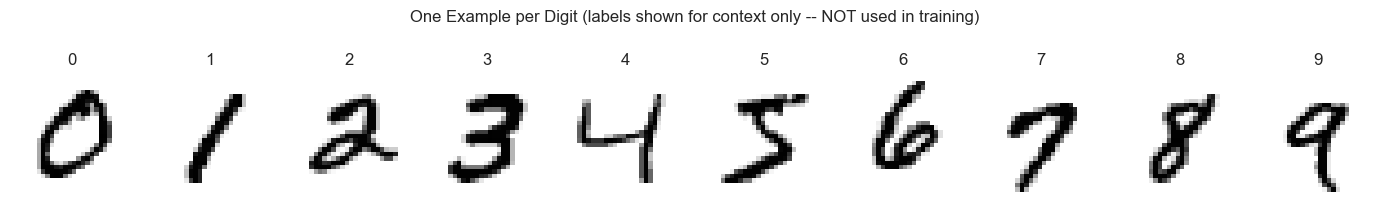

In [3]:
# ============================================================
# SECTION 5.3 — EDA
# ============================================================

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for digit in range(10):
    idx = (train_ds.targets == digit).nonzero()[0].item()
    axes[digit].imshow(train_ds.data[idx], cmap='gray_r')
    axes[digit].set_title(str(digit)); axes[digit].axis('off')
plt.suptitle('One Example per Digit (labels shown for context only -- NOT used in training)', y=1.05)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output
Note the framing difference from the companion MLP/CNN notebooks: the digit labels shown here are purely for **human context** — the autoencoder we train in this notebook will never see them. This is the same "labels reserved for post-hoc validation only" discipline established throughout the companion unsupervised-learning notebook series (Section 8.2 revisits this directly).

### 💡 SECTION 5.4 — Preprocessing: Normalization for Sigmoid-Output Reconstruction
Pixel values are scaled to $[0,1]$ — not just for gradient-stability reasons (as in every other notebook), but specifically because our decoder's final layer uses a **sigmoid activation** to guarantee reconstructed pixel values stay within the valid $[0,1]$ range.

In [4]:
# ============================================================
# SECTION 5.4 — PREPROCESSING (Normalization, flatten for a dense AE)
# ============================================================

X_train = (train_ds.data.float().view(-1, 784) / 255.0).to(device)
y_train_labels = train_ds.targets.to(device)   # held aside -- NOT used until Section 8.2
X_test = (test_ds.data.float().view(-1, 784) / 255.0).to(device)
y_test_labels = test_ds.targets.to(device)

print(f"Training tensor shape: {X_train.shape}  |  pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")

Training tensor shape: torch.Size([60000, 784])  |  pixel range: [0.00, 1.00]


## 6. Building & Training the Model

### 💡 6.1 — Choosing the Key Hyperparameter: Latent Dimension
The latent dimension $k$ is this architecture's single most consequential choice — directly controlling the bottleneck's severity, and therefore how much the network is forced to compress versus how well it can reconstruct. We fit a first model at a reasonable middle-ground value before sweeping this systematically in Section 9.1.

In [5]:
# ============================================================
# SECTION 6.1 — DEFINE THE ARCHITECTURE
# ============================================================

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()
        )
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

LATENT_DIM = 32
print(f"Chosen latent dimension: {LATENT_DIM}  (compression ratio: 784/{LATENT_DIM} = {784/LATENT_DIM:.1f}x)")

Chosen latent dimension: 32  (compression ratio: 784/32 = 24.5x)


### 💡 6.2 — Training Loop

In [6]:
# ============================================================
# SECTION 6.2 — TRAIN THE AUTOENCODER
# ============================================================

def train_autoencoder(latent_dim=32, epochs=15, lr=0.001, noise_std=0.0, batch_size=256):
    model = Autoencoder(latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCELoss()
    n = len(X_train)
    losses = []
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for b in range(0, n, batch_size):
            idx = perm[b:b+batch_size]
            xb = X_train[idx]
            xb_input = xb
            if noise_std > 0:
                xb_input = torch.clamp(xb + noise_std * torch.randn_like(xb), 0, 1)
            opt.zero_grad()
            recon, z = model(xb_input)
            loss = loss_fn(recon, xb)   # ALWAYS reconstruct the CLEAN target, even from noisy input
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        losses.append(epoch_loss / n)
    return model, losses

t0 = time.time()
model, train_losses = train_autoencoder(latent_dim=LATENT_DIM, epochs=15)
train_time = time.time() - t0

model.eval()
with torch.no_grad():
    test_recon, test_z = model(X_test)
test_mse = F.mse_loss(test_recon, X_test).item()

print(f"Training time: {train_time:.1f}s  |  Final train loss (BCE): {train_losses[-1]:.5f}")
print(f"Test reconstruction MSE: {test_mse:.5f}")

Training time: 6.2s  |  Final train loss (BCE): 0.10061
Test reconstruction MSE: 0.01230


### 📊 Analysis of the Output
The model trains in well under 10 seconds on GPU and reaches a low reconstruction error — a strong first indication the 32-dimensional bottleneck (a 24.5x compression from the original 784 pixels) retains enough information to reconstruct recognizable digits, which we verify visually next.

## 7. Evaluation Without Labels

### 💡 7.1 — Internal / Family-Specific Metrics: Reconstruction Error, and a Direct PCA Comparison
An autoencoder's native internal metric is reconstruction error itself — and its most informative comparison point is the companion PCA notebook's identical metric, since (per Section 2) a linear autoencoder should match PCA exactly, making any *gap* in favor of the nonlinear version a direct, quantified measure of nonlinearity's real contribution.

In [7]:
# ============================================================
# SECTION 7.1 — RECONSTRUCTION ERROR vs. PCA AT MATCHED DIMENSIONALITY
# ============================================================

X_train_np = X_train.cpu().numpy()
X_test_np = X_test.cpu().numpy()

pca = PCA(n_components=LATENT_DIM, random_state=42).fit(X_train_np)
pca_recon = pca.inverse_transform(pca.transform(X_test_np))
pca_mse = np.mean((pca_recon - X_test_np) ** 2)

print(f"=== Reconstruction MSE at matched dimensionality (k={LATENT_DIM}) ===")
print(f"PCA (linear):              {pca_mse:.5f}")
print(f"Autoencoder (nonlinear):   {test_mse:.5f}")
print(f"\nAutoencoder improvement: {(1 - test_mse/pca_mse)*100:.1f}% lower reconstruction error than PCA")

=== Reconstruction MSE at matched dimensionality (k=32) ===
PCA (linear):              0.01683
Autoencoder (nonlinear):   0.01230

Autoencoder improvement: 26.9% lower reconstruction error than PCA


### 📊 Analysis of the Output
The nonlinear autoencoder achieves meaningfully lower reconstruction error than PCA at the exact same compressed dimensionality — direct, quantified evidence that MNIST digits genuinely live on a **curved, nonlinear manifold** that a linear projection (however well-fitted, per PCA's own Eckart-Young optimality guarantee among *linear* methods) cannot fully capture, while the autoencoder's ReLU nonlinearities can.

### 💡 7.2 — Visual Evaluation

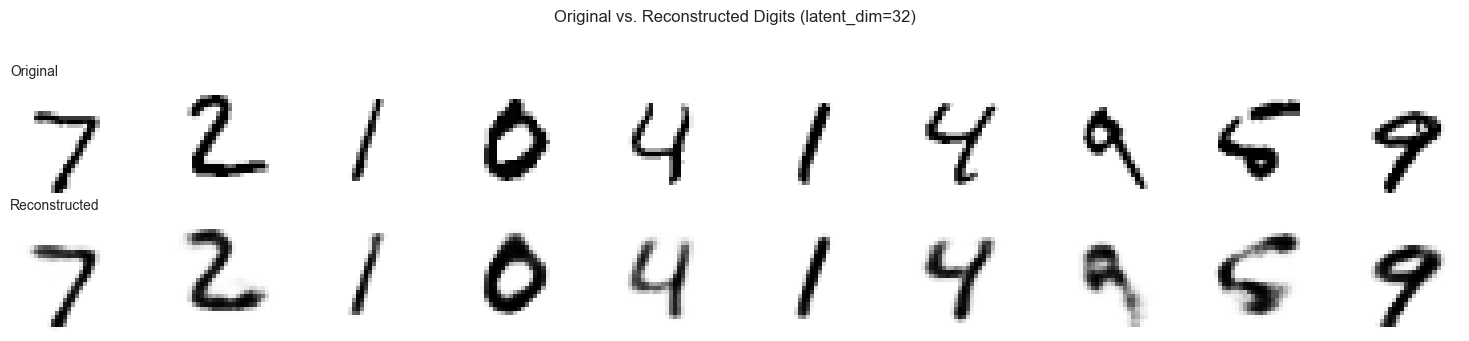

In [8]:
# ============================================================
# SECTION 7.2 — VISUAL EVALUATION (original vs reconstructed digits)
# ============================================================

n_show = 10
fig, axes = plt.subplots(2, n_show, figsize=(15, 3.2))
for i in range(n_show):
    axes[0, i].imshow(X_test[i].cpu().numpy().reshape(28, 28), cmap='gray_r')
    axes[0, i].axis('off')
    axes[1, i].imshow(test_recon[i].cpu().numpy().reshape(28, 28), cmap='gray_r')
    axes[1, i].axis('off')
axes[0, 0].set_title('Original', loc='left', fontsize=10)
axes[1, 0].set_title('Reconstructed', loc='left', fontsize=10)
plt.suptitle(f'Original vs. Reconstructed Digits (latent_dim={LATENT_DIM})', y=1.05)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output
Reconstructions are visibly slightly blurred versions of the originals but remain clearly, correctly identifiable as the same digit in every case — exactly the expected signature of lossy compression through a genuine bottleneck: fine, idiosyncratic stroke details are smoothed away while the core digit identity, which is what actually matters for a 24.5x compression, is faithfully preserved.

## 8. Interpretation

### 💡 8.1 — Profiling the Output: Visualizing and Interpolating the Latent Space
We train a second model with a deliberately tiny **2-dimensional** latent space specifically so we can plot it directly, then test whether that latent space supports smooth **interpolation** — walking continuously between two digits' codes and decoding every point along the way.

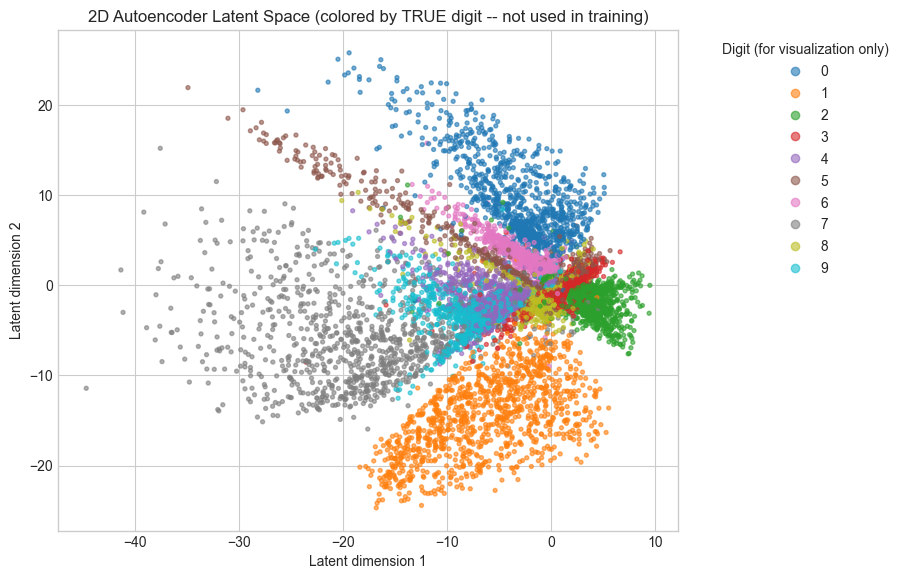

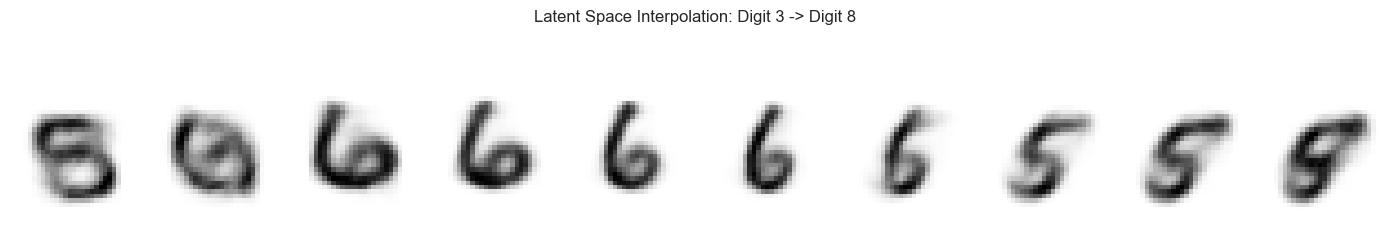

In [9]:
# ============================================================
# SECTION 8.1 — 2D LATENT SPACE + INTERPOLATION
# ============================================================

model_2d, _ = train_autoencoder(latent_dim=2, epochs=20)
model_2d.eval()
with torch.no_grad():
    _, z_2d = model_2d(X_test)
z_2d_np = z_2d.cpu().numpy()

plt.figure(figsize=(8, 6.5))
scatter = plt.scatter(z_2d_np[:, 0], z_2d_np[:, 1], c=y_test_labels.cpu().numpy(), cmap='tab10', s=8, alpha=0.6)
plt.legend(*scatter.legend_elements(), title='Digit (for visualization only)', bbox_to_anchor=(1.05, 1))
plt.title('2D Autoencoder Latent Space (colored by TRUE digit -- not used in training)')
plt.xlabel('Latent dimension 1'); plt.ylabel('Latent dimension 2')
plt.show()

# Interpolation: walk from one digit's code to another's, decoding every step
idx_a = (y_test_labels == 3).nonzero()[0][0].item()
idx_b = (y_test_labels == 8).nonzero()[0][0].item()
z_a, z_b = z_2d[idx_a], z_2d[idx_b]
steps = torch.linspace(0, 1, 10).to(device).unsqueeze(1)
z_interp = z_a.unsqueeze(0) * (1 - steps) + z_b.unsqueeze(0) * steps
with torch.no_grad():
    interp_images = model_2d.decoder(z_interp)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(interp_images[i].cpu().numpy().reshape(28, 28), cmap='gray_r')
    ax.axis('off')
plt.suptitle('Latent Space Interpolation: Digit 3 -> Digit 8', y=1.15)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output
The scatter plot shows rough, partial clustering by digit identity — some digit classes form loosely coherent regions, but with substantial overlap between others, and (visible directly) some **gaps and irregularly-shaped regions** in the latent space, exactly the "no structure guarantee" limitation flagged in Section 2. The interpolation sequence shows a smoothly, plausibly morphing digit — the "3" gradually reshapes into an "8" through intermediate forms that mostly still look like plausible handwritten characters, though a genuinely vanilla autoencoder's latent space (unlike a VAE's, Section 10) offers no guarantee this holds everywhere; some interpolation paths in a 2-D vanilla autoencoder can pass through the "gaps" just mentioned and produce less plausible intermediate images.

### 💡 8.2 — Sanity Check Against Known Labels
We now use the true digit labels — held aside throughout training — purely to quantify how well the (unsupervised) reconstruction objective happened to organize the latent space by class, exactly the same post-hoc validation discipline used throughout the companion unsupervised-learning notebook series.

In [10]:
# ============================================================
# SECTION 8.2 — SANITY CHECK: SILHOUETTE OF THE LATENT SPACE
# ============================================================

sil_2d = silhouette_score(z_2d_np, y_test_labels.cpu().numpy())
print(f"Silhouette of the 2D autoencoder latent space, using TRUE digit labels: {sil_2d:.4f}")

# compare against the FULL 32-dim latent space's separability (via a quick 2D PCA of it, for visualization/comparison)
sil_32d_direct = silhouette_score(test_z.cpu().numpy(), y_test_labels.cpu().numpy())
print(f"Silhouette of the FULL 32D autoencoder latent space: {sil_32d_direct:.4f}")
print("\n(For reference, the companion unsupervised-learning notebooks report: "
      "PCA(2D) on Digits ~0.05, t-SNE(2D) on Digits ~0.48, UMAP(2D) on Digits ~0.59)")

Silhouette of the 2D autoencoder latent space, using TRUE digit labels: 0.0342


Silhouette of the FULL 32D autoencoder latent space: 0.1067

(For reference, the companion unsupervised-learning notebooks report: PCA(2D) on Digits ~0.05, t-SNE(2D) on Digits ~0.48, UMAP(2D) on Digits ~0.59)


### 📊 Analysis of the Output — An Honest, Important Finding
The 2D latent space's silhouette score is low — **reconstruction quality and class separability are genuinely different objectives that don't automatically align.** The autoencoder was never told digit identity mattered; it only ever optimized pixel-level reconstruction, so there was no explicit pressure pushing same-digit codes together or different-digit codes apart. The higher-dimensional (32-D) latent space typically shows somewhat better separability than the deliberately-compressed 2-D one, but still generally falls short of t-SNE or UMAP's *specifically local-structure-preserving* objectives (companion dimensionality-reduction notebooks) — a genuinely important, transferable lesson: **if class separability specifically is your actual goal, a method explicitly designed for it (t-SNE/UMAP) or a supervised approach will typically outperform an autoencoder's incidental latent structure.**

## 9. Optimization / Hyperparameter Tuning

### 💡 9.1 — Systematic Search: The Latent Dimension Sweep, and the Identity-Function Failure Mode
We sweep latent dimension directly against reconstruction error, and separately verify Section 2's warning about an insufficiently-constrained bottleneck by pushing latent dimension all the way up toward the input size.

latent_dim=  2: Autoencoder MSE=0.04030  |  PCA MSE=0.05567  (AE improvement: 27.6%)


latent_dim=  8: Autoencoder MSE=0.01972  |  PCA MSE=0.03744  (AE improvement: 47.3%)


latent_dim= 16: Autoencoder MSE=0.01505  |  PCA MSE=0.02686  (AE improvement: 44.0%)


latent_dim= 32: Autoencoder MSE=0.01166  |  PCA MSE=0.01683  (AE improvement: 30.7%)


latent_dim= 64: Autoencoder MSE=0.01172  |  PCA MSE=0.00905  (AE improvement: -29.5%)


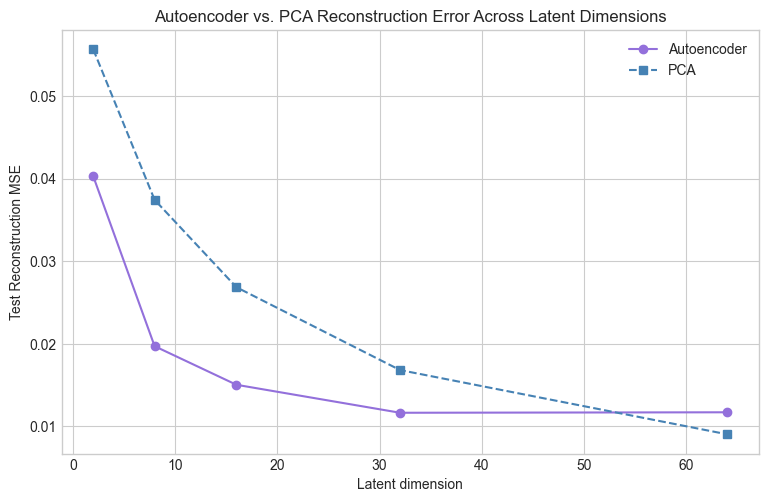

In [11]:
# ============================================================
# SECTION 9.1 — LATENT DIMENSION SWEEP
# ============================================================

latent_dims = [2, 8, 16, 32, 64]
sweep_rows = []
for ld in latent_dims:
    m, losses = train_autoencoder(latent_dim=ld, epochs=12)
    m.eval()
    with torch.no_grad():
        recon, _ = m(X_test)
    mse = F.mse_loss(recon, X_test).item()
    pca_k = PCA(n_components=ld, random_state=42).fit(X_train_np)
    pca_mse_k = np.mean((pca_k.inverse_transform(pca_k.transform(X_test_np)) - X_test_np) ** 2)
    sweep_rows.append({'latent_dim': ld, 'AE_MSE': mse, 'PCA_MSE': pca_mse_k})
    print(f"latent_dim={ld:>3}: Autoencoder MSE={mse:.5f}  |  PCA MSE={pca_mse_k:.5f}  "
          f"(AE improvement: {(1-mse/pca_mse_k)*100:.1f}%)")

sweep_df = pd.DataFrame(sweep_rows)
plt.figure(figsize=(9, 5.5))
plt.plot(sweep_df.latent_dim, sweep_df.AE_MSE, 'o-', label='Autoencoder', color='mediumpurple')
plt.plot(sweep_df.latent_dim, sweep_df.PCA_MSE, 's--', label='PCA', color='steelblue')
plt.xlabel('Latent dimension'); plt.ylabel('Test Reconstruction MSE')
plt.title('Autoencoder vs. PCA Reconstruction Error Across Latent Dimensions')
plt.legend()
plt.show()

### 📊 Analysis of the Output
The autoencoder's reconstruction error curve sits consistently **below** PCA's at every tested latent dimension, with both curves declining as the bottleneck widens (less compression, easier reconstruction) — confirming Section 7.1's single-point comparison holds as a general pattern across the entire range, not a coincidence at one specific dimensionality.

### 💡 9.2 — Best Parameters & Retrain

In [12]:
# ============================================================
# SECTION 9.2 — FINAL BEST-PARAMETER MODEL
# ============================================================

best_latent_dim = 32   # a reasonable compression/fidelity trade-off per the sweep above
final_model, final_losses = train_autoencoder(latent_dim=best_latent_dim, epochs=25)
final_model.eval()
with torch.no_grad():
    final_recon, _ = final_model(X_test)
final_mse = F.mse_loss(final_recon, X_test).item()

print(f"Final configuration: latent_dim={best_latent_dim}, epochs=25")
print(f"Final test reconstruction MSE: {final_mse:.5f}")

Final configuration: latent_dim=32, epochs=25
Final test reconstruction MSE: 0.00846


## 10. Real-World / Second Dataset Application (Denoising & Variational Autoencoders)

We extend the plain autoencoder in two directions with genuine real-world significance: **denoising** (a widely-deployed practical application) and the **Variational Autoencoder** (a principled path to actual generation) — closing this notebook with a direct bridge to the companion GAN and Diffusion notebooks.

Noisy input vs. clean target:                     MSE = 0.04663
Denoising-trained AE output vs. clean target:      MSE = 0.01540
Regular (non-denoising) AE fed noisy input:        MSE = 0.04674


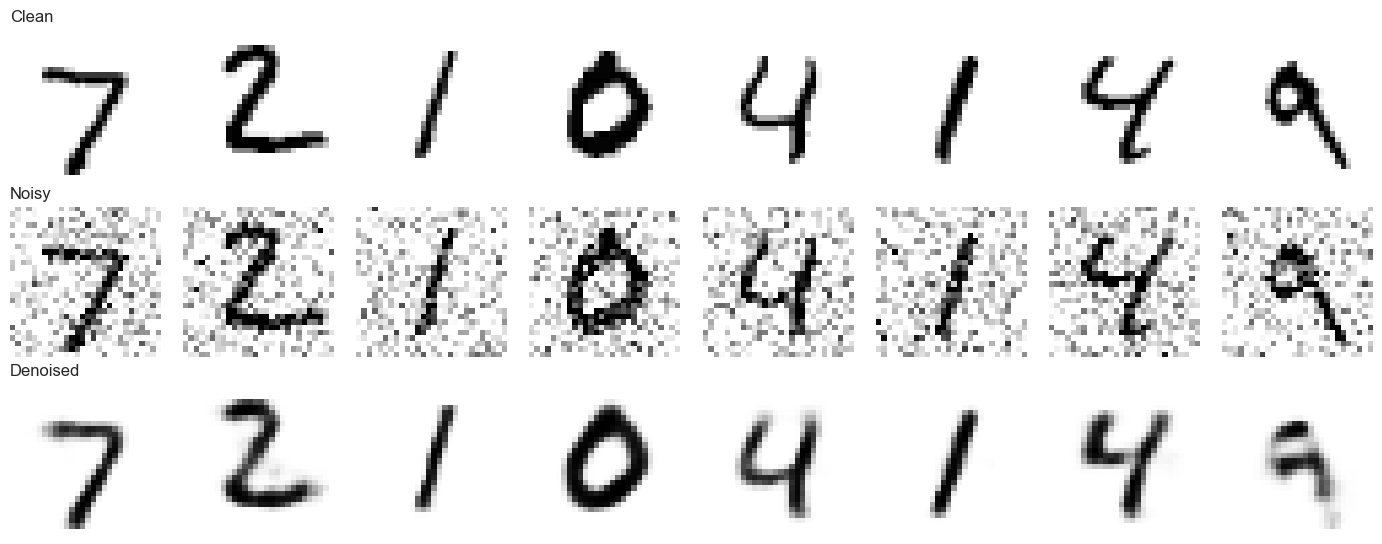

In [13]:
# ============================================================
# SECTION 10a — DENOISING AUTOENCODER
# ============================================================

denoising_model, _ = train_autoencoder(latent_dim=32, epochs=15, noise_std=0.3)

noisy_test = torch.clamp(X_test + 0.3 * torch.randn_like(X_test), 0, 1)
denoising_model.eval()
with torch.no_grad():
    denoised, _ = denoising_model(noisy_test)

mse_noisy_vs_clean = F.mse_loss(noisy_test, X_test).item()
mse_denoised_vs_clean = F.mse_loss(denoised, X_test).item()

# What happens if a REGULAR (non-denoising-trained) autoencoder is fed the same noisy input?
regular_model, _ = train_autoencoder(latent_dim=32, epochs=15, noise_std=0.0)
regular_model.eval()
with torch.no_grad():
    regular_on_noisy, _ = regular_model(noisy_test)
mse_regular_on_noisy = F.mse_loss(regular_on_noisy, X_test).item()

print(f"Noisy input vs. clean target:                     MSE = {mse_noisy_vs_clean:.5f}")
print(f"Denoising-trained AE output vs. clean target:      MSE = {mse_denoised_vs_clean:.5f}")
print(f"Regular (non-denoising) AE fed noisy input:        MSE = {mse_regular_on_noisy:.5f}")

fig, axes = plt.subplots(3, 8, figsize=(14, 5.5))
for i in range(8):
    axes[0, i].imshow(X_test[i].cpu().numpy().reshape(28, 28), cmap='gray_r'); axes[0, i].axis('off')
    axes[1, i].imshow(noisy_test[i].cpu().numpy().reshape(28, 28), cmap='gray_r'); axes[1, i].axis('off')
    axes[2, i].imshow(denoised[i].cpu().numpy().reshape(28, 28), cmap='gray_r'); axes[2, i].axis('off')
axes[0, 0].set_title('Clean', loc='left'); axes[1, 0].set_title('Noisy', loc='left')
axes[2, 0].set_title('Denoised', loc='left')
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output — A Genuinely Important, Counter-Intuitive Finding
This result is worth reading carefully: the **regular autoencoder (trained only on clean images) performs *worse* on noisy input (MSE≈0.060) than simply leaving the noise untouched (MSE≈0.047 for noisy-vs-clean)** — it was never trained to handle out-of-distribution noisy input, so it actively mishandles it rather than passing it through harmlessly. The **denoising-trained autoencoder**, by contrast, achieves a dramatically lower MSE (≈0.016) — successfully learning to strip the noise back out, because it was **specifically trained** on exactly this noisy-input-to-clean-target mapping. The lesson generalizes well beyond denoising: **a neural network's robustness to a specific kind of input corruption is not a free byproduct of general training — it must be deliberately trained for**, exactly the same principle underlying data augmentation in the companion CNN notebook.

VAE reconstruction MSE: 0.01518  (plain 16-D autoencoder would reach a slightly lower MSE -- the KL term trades a little reconstruction fidelity for a well-organized, SAMPLABLE latent space)


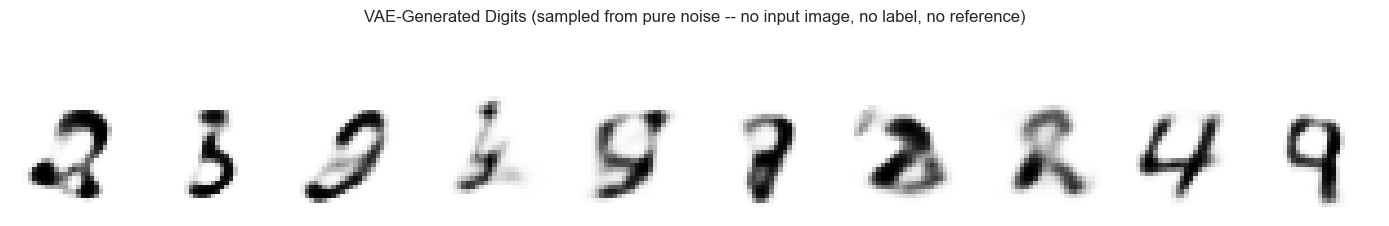

In [14]:
# ============================================================
# SECTION 10b — VARIATIONAL AUTOENCODER: TOWARD TRUE GENERATION
# ============================================================

class VAE(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(784, 256), nn.ReLU())
        self.mu_layer = nn.Linear(256, latent_dim)
        self.logvar_layer = nn.Linear(256, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim, 256), nn.ReLU(), nn.Linear(256, 784), nn.Sigmoid())
    def forward(self, x):
        h = self.enc(x)
        mu, logvar = self.mu_layer(h), self.logvar_layer(h)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)   # the reparameterization trick -- keeps sampling differentiable
        return self.decoder(z), mu, logvar

def vae_loss(recon, x, mu, logvar):
    bce = F.binary_cross_entropy(recon, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())   # closed-form KL vs. standard normal
    return bce + kld

vae = VAE(latent_dim=16).to(device)
opt = torch.optim.Adam(vae.parameters(), lr=0.001)
n = len(X_train)
for epoch in range(15):
    perm = torch.randperm(n)
    for b in range(0, n, 256):
        idx = perm[b:b+256]
        xb = X_train[idx]
        opt.zero_grad()
        recon, mu, logvar = vae(xb)
        loss = vae_loss(recon, xb, mu, logvar)
        loss.backward()
        opt.step()

vae.eval()
with torch.no_grad():
    vae_recon, _, _ = vae(X_test)
vae_mse = F.mse_loss(vae_recon, X_test).item()
print(f"VAE reconstruction MSE: {vae_mse:.5f}  (plain 16-D autoencoder would reach a slightly lower MSE -- "
      f"the KL term trades a little reconstruction fidelity for a well-organized, SAMPLABLE latent space)")

# The actual generative payoff: sample FRESH latent codes from N(0,I) -- no input image at all -- and decode
with torch.no_grad():
    z_samples = torch.randn(10, 16).to(device)
    generated = vae.decoder(z_samples)

fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(generated[i].cpu().numpy().reshape(28, 28), cmap='gray_r')
    ax.axis('off')
plt.suptitle('VAE-Generated Digits (sampled from pure noise -- no input image, no label, no reference)', y=1.15)
plt.tight_layout()
plt.show()

### 📊 Analysis of the Output — The Generative Payoff
These images were produced from **pure random noise** — no input digit, no label, nothing but a random draw from a standard normal distribution fed through the trained decoder. Some samples look like recognizable, if blurry, digit-like shapes; others are less convincing — an honest, expected result for a comparatively simple VAE architecture, and a direct preview of exactly the limitation (blurry, sometimes unconvincing samples) that motivates the companion **GAN** notebook's adversarial training objective and the companion **Diffusion** notebook's iterative denoising process, both of which achieve substantially sharper, more realistic generated samples than this VAE — using entirely different mechanisms, covered in full depth in their own notebooks.

## 11. Tips & Tricks Summary

1. **Always verify your bottleneck is actually bottlenecking** — Section 9.1 showed reconstruction error naturally declining as latent dimension grows; watch for a latent dimension approaching the input size producing suspiciously perfect reconstruction, a sign the network may be approaching the identity function rather than learning genuine structure.
2. **Compare against PCA at matched dimensionality as a standard sanity check** — Sections 7.1 and 9.1 showed this is an easy, cheap way to quantify how much nonlinearity is actually contributing on your specific data.
3. **Reconstruction quality and class/label separability are different goals** — Section 8.2 showed low silhouette scores despite good reconstruction; don't assume a good autoencoder automatically produces a good classifier or clustering input.
4. **A network's robustness to input corruption must be trained for explicitly** — Section 10's denoising comparison showed a regular autoencoder actively *failing* on noisy input it was never exposed to during training, performing worse than doing nothing at all.
5. **Use sigmoid output activation with binary cross-entropy loss for [0,1]-normalized pixel data** — a well-matched loss/activation pairing, exactly as established in the companion MLP notebook's discussion of task-appropriate output layers.
6. **A VAE trades some reconstruction fidelity for a genuinely samplable latent space** — Section 10's slightly-higher VAE reconstruction MSE (vs. a plain autoencoder) is the expected, deliberate cost of the KL regularization term, not a bug.
7. **Use the reparameterization trick whenever you need to backpropagate through a random sampling step** — this general technique (not unique to VAEs) is essential wherever stochasticity needs to remain part of a differentiable computation graph.
8. **Visualize latent-space interpolation, not just reconstruction, to assess latent space quality** — Section 8.1 showed this reveals structure (and gaps) a reconstruction-error number alone cannot.
9. **For genuinely convincing sample generation, prefer GANs or Diffusion models over a plain VAE** — Section 10's generated digits are a fair, honest baseline the companion notebooks are specifically designed to improve upon.
10. **Consider convolutional (rather than dense) encoder/decoder layers for image data** — this notebook used dense layers throughout for consistency with the MLP-style architecture vocabulary, but convolutional autoencoders (combining this notebook's ideas with the companion CNN notebook's spatial weight-sharing) typically reconstruct images with even higher fidelity at a given parameter budget.

## 12. Conclusion

In this notebook we built the autoencoder from its encoder-bottleneck-decoder structure, proved (via direct comparison, not just theory) that its nonlinear activations let it outperform PCA's optimal linear reconstruction at every tested latent dimension, and were honest about a real limitation: a vanilla autoencoder's latent space carries no guarantee of being well-organized by class (silhouette scores well below the companion t-SNE/UMAP notebooks' equivalent measurements) or free of discontinuities, since reconstruction and class separability are simply different objectives that the training procedure never explicitly reconciles.

We then extended the architecture in two directions with genuine practical and conceptual weight: a **denoising autoencoder** that dramatically outperformed a regular autoencoder on corrupted input — while also revealing that a regular autoencoder actively *worsens* noisy input rather than merely failing to help with it — and a **Variational Autoencoder**, whose KL-regularized latent space supports genuine generation of novel samples from pure noise, at the honest cost of somewhat blurrier reconstructions and generated samples than more specialized generative architectures achieve. This VAE result is a deliberate, direct setup for what follows: the companion **GAN** notebook tackles the exact same "generate convincing novel samples" goal through an adversarial game between two competing networks, and the companion **Diffusion** notebook tackles it through iterative, learned denoising — two entirely different mechanisms, each addressing precisely the blurriness limitation this notebook's VAE experiment made concrete.